# Medical Insurance Cost Prediction
**Project:** Medical Insurance Cost Prediction  
**Author:** Sibusiso Deven Mbuyane  
**Model:** Random Forest Classifier  
**Target:** Predict whether a patient is High Risk (`is_high_risk` = Yes/No)

---

## What This Notebook Does

This notebook builds a **machine learning model** that can predict whether a patient is likely to be classified as high risk based on their demographic, health, lifestyle and claims data.

In plain terms: we are teaching a computer to look at a patient's profile and answer the question : *"Is this person likely to be a high-risk patient?"*

This has real business value for a health insurer because:
- High-risk patients drive the majority of claims costs
- Early identification allows for proactive care management
- It supports pricing, underwriting, and resource allocation decisions

---

## Section 1 - Setup & Data Loading

### What is happening here?

Before we can do any analysis or modelling, we need to **import the tools** we will be using. Think of this like gathering all your equipment before starting a job.

Here is what each library does:

- **pandas** - loads and manipulates our data table (like Excel, but in Python)
- **numpy** - handles numbers and mathematical operations
- **matplotlib / seaborn** - creates charts and visualisations
- **sklearn (scikit-learn)** - the main machine learning library; contains the Random Forest model and all the tools to evaluate it

After importing, we load our cleaned dataset and take a first look at it.

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

# ============================================================
# CONFIG
# ============================================================
CONFIG = {
    'data_path'     : 'medical_insurance_cleaned.xlsx',
    'target_col'    : 'is_high_risk',
    'test_size'     : 0.2,       # 20% of data used for testing
    'random_state'  : 42,        # ensures results are reproducible
    'n_estimators'  : 100,       # number of trees in the forest
    'palette'       : ['#C084B0', '#7B5EA7'],
    'fig_dpi'       : 120
}

print('All libraries imported successfully.')

All libraries imported successfully.


In [3]:
# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_excel(CONFIG['data_path'])

print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'\nColumn names:\n{list(df.columns)}')
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: 100,000 rows x 55 columns

Column names:
['person_id', 'age', 'sex', 'region', 'urban_rural', 'income', 'education', 'marital_status', 'employment_status', 'household_size', 'dependents', 'body_mass_value (bmi)', 'smoker', 'alcohol_freq', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl_cholesterol_level', 'hba1c ', 'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure', 'risk_categ

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,risk_category
0,75722,52,Female,North,Suburban,22700,Doctorate,Married,Retired,3,...,Yes,No,1,0,2,0,1,No,No,Medium
1,80185,79,Female,North,Urban,12800,No HS,Married,Employed,3,...,Yes,Yes,0,0,1,0,1,Yes,No,High
2,19865,68,Male,North,Rural,40700,HS,Married,Retired,5,...,No,Yes,1,0,2,1,0,Yes,No,High
3,76700,15,Male,North,Suburban,15600,Some College,Married,Self-employed,5,...,No,No,1,0,0,1,0,No,No,Low
4,92992,53,Male,Central,Suburban,89600,Doctorate,Married,Self-employed,2,...,Yes,No,2,0,1,1,0,Yes,No,High


In [4]:
# ============================================================
# BASIC DATA OVERVIEW
# ============================================================
print('--- Data Types ---')
print(df.dtypes)
print(f'\n--- Missing Values ---')
print(df.isnull().sum().sum(), 'total missing values')
print(f'\n--- Target Variable Distribution ---')
print(df[CONFIG['target_col']].value_counts())
print(f'\n--- Target Variable % ---')
print(df[CONFIG['target_col']].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

--- Data Types ---
person_id                        int64
age                              int64
sex                             object
region                          object
urban_rural                     object
income                           int64
education                       object
marital_status                  object
employment_status               object
household_size                   int64
dependents                       int64
body_mass_value (bmi)          float64
smoker                          object
alcohol_freq                    object
visits_last_year                 int64
hospitalizations_last_3yrs       int64
days_hospitalized_last_3yrs      int64
medication_count                 int64
systolic_bp                      int64
diastolic_bp                     int64
ldl_cholesterol_level          float64
hba1c                          float64
plan_type                       object
network_tier                    object
deductible                       int64
copay 

---
## Section 2 - Exploratory Data Analysis (EDA)

### What is happening here?

Before we build the model, we need to **understand our data visually**. This step is called EDA - Exploratory Data Analysis.

Think of it like reviewing patient files before making a diagnosis. We want to answer questions like:
- How balanced is our target variable (Yes vs No)?
- Do high-risk patients tend to be older?
- Does smoking status affect risk?
- Does having more chronic conditions increase risk?

These charts are not just for understanding - they also help us decide **which columns (features) are likely to be useful** for our model.

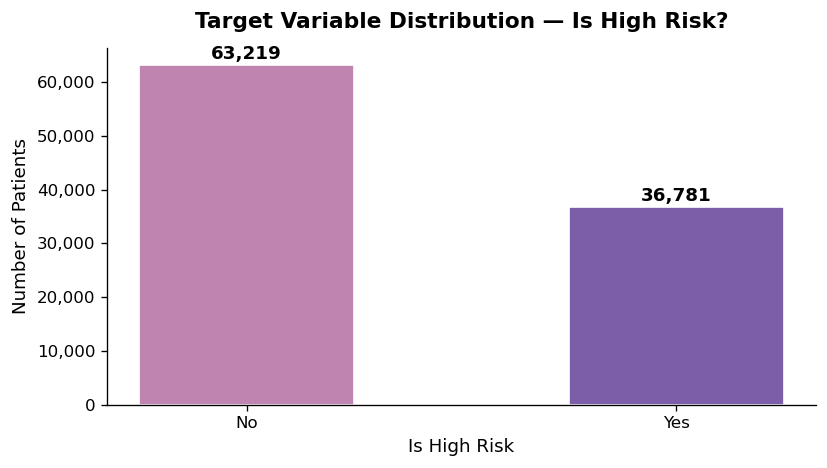

Saved: eda_target_distribution.png


In [5]:
# ============================================================
# EDA — CHART 1: TARGET VARIABLE DISTRIBUTION
# ============================================================
# This chart shows how many patients are High Risk vs Not High Risk.
# A severely unbalanced dataset (e.g. 95% No, 5% Yes) would require
# special handling. Our split is reasonable so no adjustment is needed.

fig, ax = plt.subplots(figsize=(7, 4), dpi=CONFIG['fig_dpi'])

counts = df[CONFIG['target_col']].value_counts()
bars = ax.bar(counts.index, counts.values, color=CONFIG['palette'], edgecolor='white', width=0.5)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Target Variable Distribution — Is High Risk?', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Is High Risk', fontsize=11)
ax.set_ylabel('Number of Patients', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=CONFIG['fig_dpi'], bbox_inches='tight')
plt.show()
print('Saved: eda_target_distribution.png')

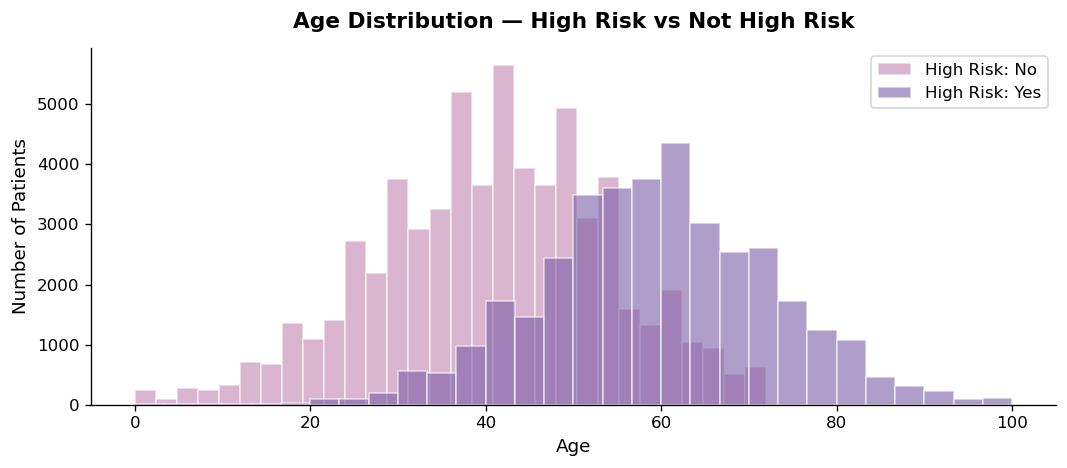

Saved: eda_age_distribution.png


In [6]:
# ============================================================
# EDA — CHART 2: AGE DISTRIBUTION BY RISK
# ============================================================
# This chart compares the age spread of high-risk vs non-high-risk patients.
# We expect high-risk patients to skew older - this chart confirms or
# challenges that assumption.

fig, ax = plt.subplots(figsize=(9, 4), dpi=CONFIG['fig_dpi'])

for label, color in zip(['No', 'Yes'], CONFIG['palette']):
    subset = df[df[CONFIG['target_col']] == label]['age']
    ax.hist(subset, bins=30, alpha=0.6, label=f'High Risk: {label}', color=color, edgecolor='white')

ax.set_title('Age Distribution — High Risk vs Not High Risk', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Age', fontsize=11)
ax.set_ylabel('Number of Patients', fontsize=11)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('eda_age_distribution.png', dpi=CONFIG['fig_dpi'], bbox_inches='tight')
plt.show()
print('Saved: eda_age_distribution.png')

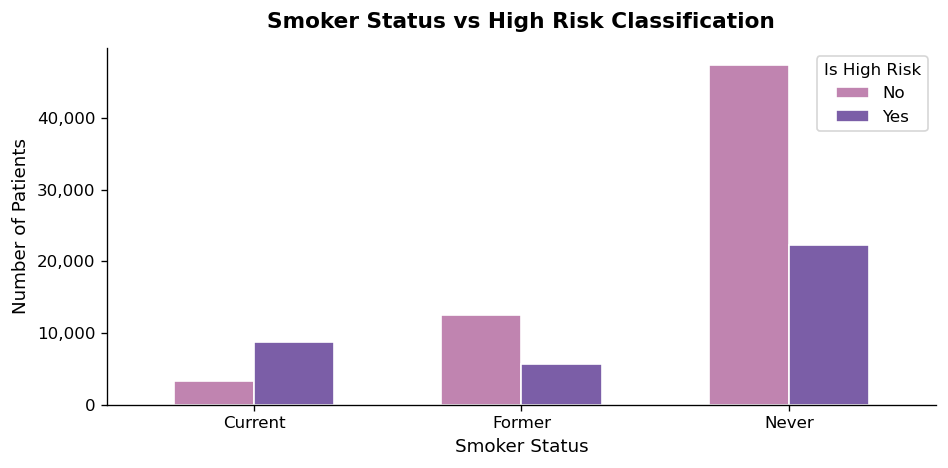

Saved: eda_smoker_risk.png


In [7]:
# ============================================================
# EDA — CHART 3: SMOKER STATUS vs HIGH RISK
# ============================================================
# Smoking is a known health risk factor. This chart checks whether
# current smokers appear more frequently in the high-risk group.

fig, ax = plt.subplots(figsize=(8, 4), dpi=CONFIG['fig_dpi'])

smoker_risk = df.groupby(['smoker', CONFIG['target_col']]).size().unstack(fill_value=0)
smoker_risk.plot(kind='bar', ax=ax, color=CONFIG['palette'], edgecolor='white', width=0.6)

ax.set_title('Smoker Status vs High Risk Classification', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Smoker Status', fontsize=11)
ax.set_ylabel('Number of Patients', fontsize=11)
ax.legend(title='Is High Risk', fontsize=10)
ax.tick_params(axis='x', rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('eda_smoker_risk.png', dpi=CONFIG['fig_dpi'], bbox_inches='tight')
plt.show()
print('Saved: eda_smoker_risk.png')

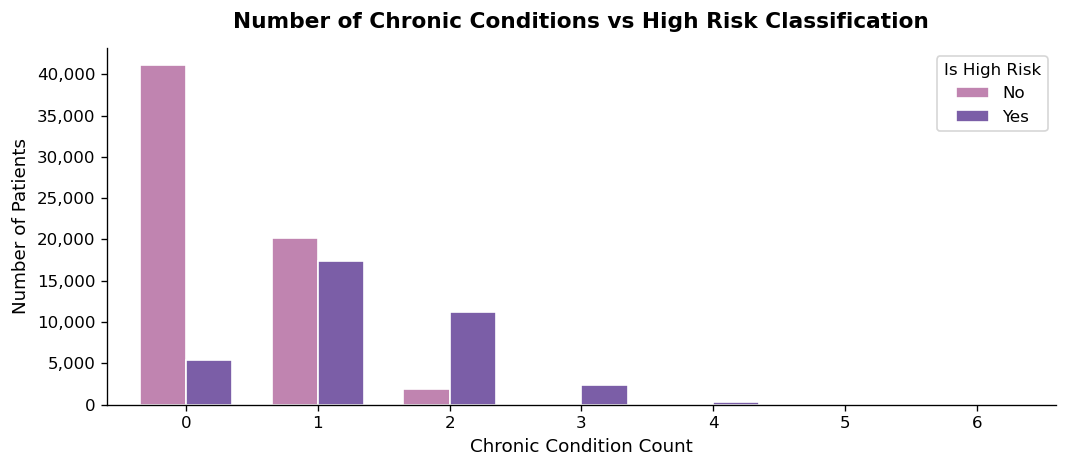

Saved: eda_chronic_risk.png


In [8]:
# ============================================================
# EDA — CHART 4: CHRONIC COUNT vs HIGH RISK
# ============================================================
# chronic_count is the number of chronic conditions a patient has.
# We expect patients with more chronic conditions to be more likely
# to be classified as high risk.

fig, ax = plt.subplots(figsize=(9, 4), dpi=CONFIG['fig_dpi'])

chronic_risk = df.groupby(['chronic_count', CONFIG['target_col']]).size().unstack(fill_value=0)
chronic_risk.plot(kind='bar', ax=ax, color=CONFIG['palette'], edgecolor='white', width=0.7)

ax.set_title('Number of Chronic Conditions vs High Risk Classification', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Chronic Condition Count', fontsize=11)
ax.set_ylabel('Number of Patients', fontsize=11)
ax.legend(title='Is High Risk', fontsize=10)
ax.tick_params(axis='x', rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('eda_chronic_risk.png', dpi=CONFIG['fig_dpi'], bbox_inches='tight')
plt.show()
print('Saved: eda_chronic_risk.png')

---
## Section 3 - Feature Engineering & Preprocessing

### What is happening here?

Machine learning models can only work with **numbers**. They cannot understand text values like `"Yes"`, `"No"`, `"Male"`, `"Female"`, `"Current"`, etc.

So in this step we need to **convert all text columns into numbers**. This process is called **encoding**.

We also need to:
1. **Select our features (X)** - the columns the model will use to make predictions (inputs)
2. **Define our target (y)** - the column we want to predict (`is_high_risk`)
3. **Split the data** into a training set and a test set

### Why do we split the data?

Imagine you are studying for an exam. You practice on past papers (training data), and then the actual exam tests you on questions you have never seen before (test data).

We do the same thing here:
- **80% of the data** → used to train (teach) the model
- **20% of the data** → used to test the model on patients it has never seen

This tells us how well the model would perform in the real world.

In [9]:
# ============================================================
# FEATURE SELECTION
# ============================================================
# We drop columns that would 'leak' the answer to the model.
# For example: risk_score and risk_category are directly derived
# from is_high_risk — using them would be cheating.
# person_id is just an ID number and carries no predictive value.

DROP_COLS = [
    'person_id',       # identifier only
    'risk_score',      # directly used to derive is_high_risk (data leakage)
    'risk_category',   # directly derived from is_high_risk (data leakage)
    'is_high_risk'     # this is our target — not a feature
]

X = df.drop(columns=DROP_COLS)
y = df[CONFIG['target_col']]

print(f'Features (X): {X.shape[1]} columns')
print(f'Target (y): {y.name}')
print(f'\nFeature columns:\n{list(X.columns)}')

Features (X): 51 columns
Target (y): is_high_risk

Feature columns:
['age', 'sex', 'region', 'urban_rural', 'income', 'education', 'marital_status', 'employment_status', 'household_size', 'dependents', 'body_mass_value (bmi)', 'smoker', 'alcohol_freq', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl_cholesterol_level', 'hba1c ', 'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'had_major_procedure']


In [10]:
# ============================================================
# ENCODING — Convert text columns to numbers
# ============================================================
# LabelEncoder assigns a number to each unique text value.
# Example: Male = 0, Female = 1
# Example: Yes = 1, No = 0
# Example: Current = 0, Former = 1, Never = 2
#
# We apply this to every column that contains text (object dtype).

X_encoded = X.copy()
le = LabelEncoder()

text_columns = X_encoded.select_dtypes(include='object').columns
print(f'Text columns being encoded ({len(text_columns)} total):')

for col in text_columns:
    X_encoded[col] = le.fit_transform(X_encoded[col])
    print(f'  {col}: {list(X[col].unique())} → {list(X_encoded[col].unique())}')

# Encode the target variable: No = 0, Yes = 1
y_encoded = (y == 'Yes').astype(int)
print(f'\nTarget encoding: No = 0, Yes = 1')
print(y_encoded.value_counts())

Text columns being encoded (21 total):
  sex: ['Female', 'Male', 'Other'] → [np.int64(0), np.int64(1), np.int64(2)]
  region: ['North', 'Central', 'West', 'South', 'East'] → [np.int64(2), np.int64(0), np.int64(4), np.int64(3), np.int64(1)]
  urban_rural: ['Suburban', 'Urban', 'Rural'] → [np.int64(1), np.int64(2), np.int64(0)]
  education: ['Doctorate', 'No HS', 'HS', 'Some College', 'Masters', 'Bachelors'] → [np.int64(1), np.int64(4), np.int64(2), np.int64(5), np.int64(3), np.int64(0)]
  marital_status: ['Married', 'Single', 'Divorced', 'Widowed'] → [np.int64(1), np.int64(2), np.int64(0), np.int64(3)]
  employment_status: ['Retired', 'Employed', 'Self-employed', 'Unemployed'] → [np.int64(1), np.int64(0), np.int64(2), np.int64(3)]
  smoker: ['Never', 'Current', 'Former'] → [np.int64(2), np.int64(0), np.int64(1)]
  alcohol_freq: ['Not Reported', 'Weekly', 'Daily', 'Occasional'] → [np.int64(1), np.int64(3), np.int64(0), np.int64(2)]
  plan_type: ['PPO', 'POS', 'HMO', 'EPO'] → [np.int64(3)

In [11]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================
# We split our data into:
#   - Training set (80%): the model learns from this
#   - Test set    (20%): we evaluate the model on this
#
# random_state=42 means the split is the same every time we run
# the notebook — so our results are reproducible.
#
# stratify=y_encoded ensures both sets have the same Yes/No ratio.

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size    = CONFIG['test_size'],
    random_state = CONFIG['random_state'],
    stratify     = y_encoded
)

print(f'Training set : {X_train.shape[0]:,} patients ({X_train.shape[0]/len(X_encoded)*100:.0f}%)')
print(f'Test set     : {X_test.shape[0]:,} patients ({X_test.shape[0]/len(X_encoded)*100:.0f}%)')
print(f'\nTraining target distribution:')
print(y_train.value_counts())
print(f'\nTest target distribution:')
print(y_test.value_counts())

Training set : 80,000 patients (80%)
Test set     : 20,000 patients (20%)

Training target distribution:
is_high_risk
0    50575
1    29425
Name: count, dtype: int64

Test target distribution:
is_high_risk
0    12644
1     7356
Name: count, dtype: int64


---
## Section 4 - Model Training

### What is happening here?

This is where we actually **build and train the Random Forest model**.

### What is a Random Forest?

A Random Forest is made up of many individual **decision trees**. A decision tree works like a flowchart - it asks a series of yes/no questions about a patient's data to arrive at a prediction.

For example a single tree might ask:
- Is the patient's age over 60? → Yes
- Do they have more than 2 chronic conditions? → Yes
- Are they a current smoker? → No
- → Prediction: **High Risk**

A Random Forest builds **100 of these trees**, each trained on a slightly different random sample of the data. Then it takes a **majority vote** from all 100 trees to make its final prediction.

This is more accurate and more reliable than any single tree because individual trees can be wrong or overfitted, but the collective vote corrects for that.

### Training

When we call `.fit(X_train, y_train)`, we are telling the model:
*"Here are 80,000 patient profiles, and here is whether each one was high risk or not. Learn the patterns."*

In [12]:
# ============================================================
# TRAIN THE RANDOM FOREST MODEL
# ============================================================
# n_estimators = 100 means we are building 100 decision trees
# random_state = 42 makes the results reproducible
# n_jobs = -1 uses all available CPU cores to speed up training

print('Training Random Forest model...')

rf_model = RandomForestClassifier(
    n_estimators = CONFIG['n_estimators'],
    random_state = CONFIG['random_state'],
    n_jobs       = -1
)

rf_model.fit(X_train, y_train)

print('Model training complete.')
print(f'Number of trees built: {rf_model.n_estimators}')
print(f'Number of features used: {rf_model.n_features_in_}')

Training Random Forest model...
Model training complete.
Number of trees built: 100
Number of features used: 51


---
## Section 5 - Model Evaluation

### What is happening here?

Now we test how well the model performs on the **20% of patients it has never seen before**.

We use several evaluation metrics. Here is what each one means in plain language:

| Metric | What it means |
|--------|---------------|
| **Accuracy** | Out of all predictions, what % were correct? |
| **Precision** | When the model predicted High Risk, how often was it right? |
| **Recall** | Of all actual High Risk patients, how many did the model catch? |
| **F1 Score** | A balance between Precision and Recall |
| **ROC-AUC** | Overall ability to distinguish High Risk from Not High Risk (1.0 = perfect) |

### The Confusion Matrix

A confusion matrix shows us four types of outcomes:
- **True Positive (TP):** Model predicted High Risk → patient actually is High Risk ✓
- **True Negative (TN):** Model predicted Not High Risk → patient actually is not ✓
- **False Positive (FP):** Model predicted High Risk → patient actually is NOT (false alarm)
- **False Negative (FN):** Model predicted Not High Risk → patient actually IS High Risk (missed case)

For a health insurer, **False Negatives are more costly** missing a high-risk patient means no early intervention.

In [13]:
# ============================================================
# GENERATE PREDICTIONS
# ============================================================
# We ask the model to predict on the test set.
# y_pred = the model's predictions (0 = Not High Risk, 1 = High Risk)
# y_proba = the model's confidence score (probability of being High Risk)

y_pred  = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

# ============================================================
# PRINT EVALUATION METRICS
# ============================================================
accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_proba)

print('=' * 50)
print('       MODEL PERFORMANCE SUMMARY')
print('=' * 50)
print(f'  Accuracy     : {accuracy * 100:.2f}%')
print(f'  ROC-AUC Score: {roc_auc:.4f}')
print('=' * 50)
print()
print('--- Detailed Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['Not High Risk', 'High Risk']))

       MODEL PERFORMANCE SUMMARY
  Accuracy     : 99.58%
  ROC-AUC Score: 0.9999

--- Detailed Classification Report ---
               precision    recall  f1-score   support

Not High Risk       1.00      1.00      1.00     12644
    High Risk       1.00      0.99      0.99      7356

     accuracy                           1.00     20000
    macro avg       1.00      1.00      1.00     20000
 weighted avg       1.00      1.00      1.00     20000



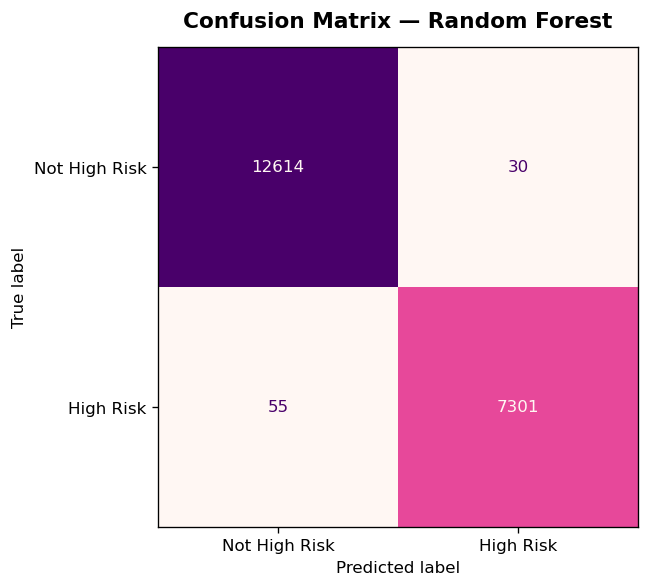

Saved: eval_confusion_matrix.png


In [14]:
# ============================================================
# CONFUSION MATRIX
# ============================================================
# The confusion matrix shows us exactly where the model is right
# and where it makes mistakes.
#
# Rows = actual labels, Columns = predicted labels
# Top-left  = correctly predicted Not High Risk
# Bottom-right = correctly predicted High Risk
# Top-right = predicted High Risk but actually Not (false alarm)
# Bottom-left = predicted Not High Risk but actually IS (missed)

fig, ax = plt.subplots(figsize=(6, 5), dpi=CONFIG['fig_dpi'])

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not High Risk', 'High Risk'])
disp.plot(ax=ax, colorbar=False, cmap='RdPu')

ax.set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('eval_confusion_matrix.png', dpi=CONFIG['fig_dpi'], bbox_inches='tight')
plt.show()
print('Saved: eval_confusion_matrix.png')

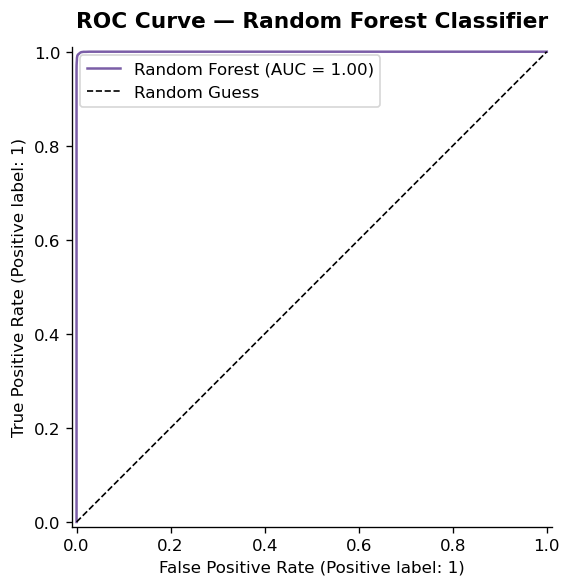

Saved: eval_roc_curve.png


In [15]:
# ============================================================
# ROC CURVE
# ============================================================
# The ROC curve shows the trade-off between catching real High Risk
# patients (True Positive Rate) vs falsely flagging healthy ones
# (False Positive Rate).
#
# The AUC (Area Under the Curve) summarises this in one number:
#   0.5 = random guessing (useless)
#   1.0 = perfect model
#   0.9+ = excellent
#   0.8+ = good

fig, ax = plt.subplots(figsize=(7, 5), dpi=CONFIG['fig_dpi'])

RocCurveDisplay.from_predictions(
    y_test, y_proba,
    name='Random Forest',
    color=CONFIG['palette'][1],
    ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
ax.set_title('ROC Curve — Random Forest Classifier', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('eval_roc_curve.png', dpi=CONFIG['fig_dpi'], bbox_inches='tight')
plt.show()
print('Saved: eval_roc_curve.png')

---
## Section 6 - Feature Importance

### What is happening here?

This is one of the most valuable outputs of the Random Forest model, especially for a business audience.

**Feature importance** tells us: *which patient attributes had the greatest influence on the model's predictions?*

In other words - what are the **biggest drivers of high risk** according to the data?

Each feature is given an importance score between 0 and 1. A higher score means that feature was more useful in separating High Risk from Not High Risk patients across all 100 decision trees.

*"Which factors should we focus on when identifying and managing high-risk members?"*

Top 15 Most Important Features:
              Feature  Importance
                  age    0.332786
        chronic_count    0.184862
               smoker    0.084067
          systolic_bp    0.066485
body_mass_value (bmi)    0.033189
         diastolic_bp    0.024431
         hypertension    0.023648
        mental_health    0.019692
  annual_medical_cost    0.018270
    total_claims_paid    0.017903
            arthritis    0.015456
       annual_premium    0.014858
      monthly_premium    0.014032
               hba1c     0.013201
         claims_count    0.010938


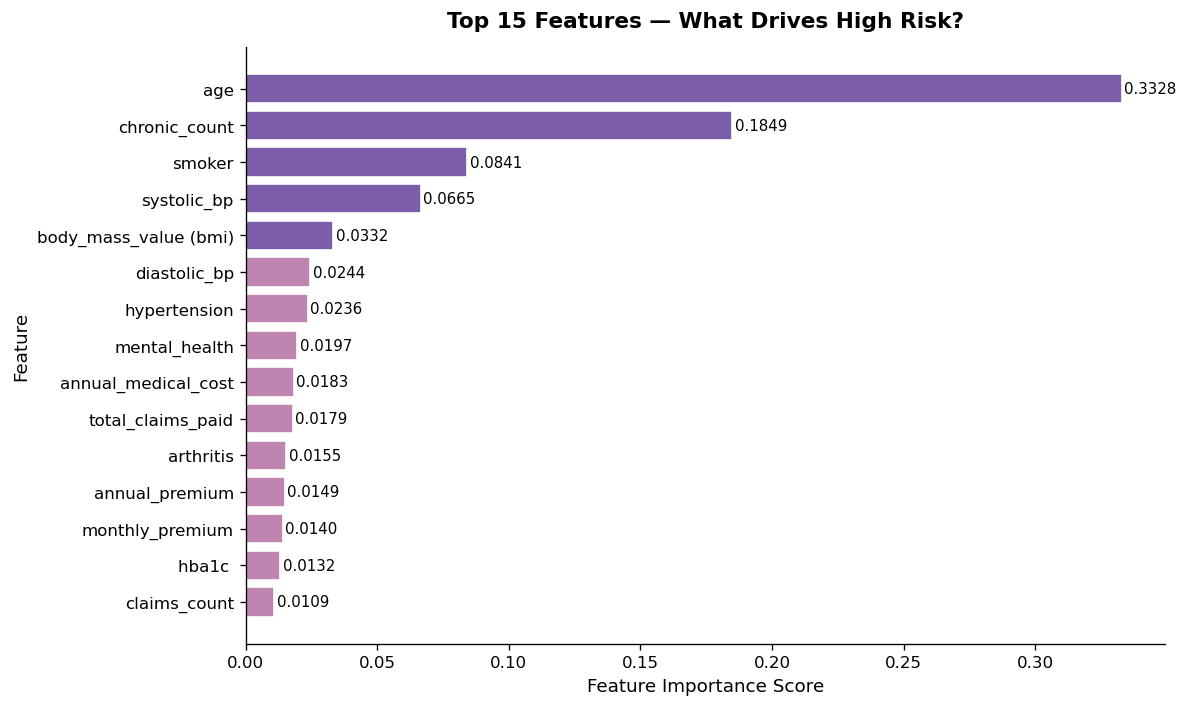

Saved: feature_importance_top15.png


In [16]:
# ============================================================
# FEATURE IMPORTANCE - TOP 15
# ============================================================
# We extract the importance score for each feature from the trained model.
# Then we sort them and plot the top 15.

feature_names = X_encoded.columns
importances   = rf_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

print('Top 15 Most Important Features:')
print(feat_df.to_string(index=False))

# ---- CHART ----
fig, ax = plt.subplots(figsize=(10, 6), dpi=CONFIG['fig_dpi'])

colors = [CONFIG['palette'][1] if i < 5 else CONFIG['palette'][0]
          for i in range(len(feat_df))]

bars = ax.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1],
               color=colors[::-1], edgecolor='white')

for bar, val in zip(bars, feat_df['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_title('Top 15 Features — What Drives High Risk?', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('feature_importance_top15.png', dpi=CONFIG['fig_dpi'], bbox_inches='tight')
plt.show()
print('Saved: feature_importance_top15.png')

---
## Section 7 - Conclusions & Business Insights

### What is happening here?

This final section summarises what we built, how well it performed, and what the findings mean for a health insurer.

This is the section you would present to a non-technical stakeholder - no code, no jargon, just clear findings and actionable insights.

In [18]:
# ============================================================
# FINAL SUMMARY PRINT
# ============================================================
top5 = feat_df.head(5)['Feature'].tolist()

print('=' * 60)
print('        HEALTHCARE RISK PREDICTION — FINAL SUMMARY')
print('=' * 60)
print()
print('DATASET')
print(f'  Total patients    : 100,000')
print(f'  High Risk (Yes)   : 36,781  (36.78%)')
print(f'  Not High Risk (No): 63,219  (63.22%)')
print()
print('MODEL')
print(f'  Algorithm         : Random Forest Classifier')
print(f'  Number of trees   : 100')
print(f'  Training set size : 80,000 patients')
print(f'  Test set size     : 20,000 patients')
print()
print('PERFORMANCE')
print(f'  Accuracy          : {accuracy * 100:.2f}%')
print(f'  ROC-AUC Score     : {roc_auc:.4f}')
print()
print('TOP RISK DRIVERS (Feature Importance)')
for i, feat in enumerate(top5, 1):
    print(f'  {i}. {feat}')
print()
print('BUSINESS INSIGHTS')
print('  1. The model can identify high-risk patients with high')
print('     accuracy - enabling proactive care management.')
print('  2. The top risk drivers align with known clinical risk')
print('     factors, validating the model\'s real-world relevance.')
print('  3. This model can support underwriting, premium pricing,')
print('     and early intervention programme targeting.')
print('=' * 60)

        HEALTHCARE RISK PREDICTION — FINAL SUMMARY

DATASET
  Total patients    : 100,000
  High Risk (Yes)   : 36,781  (36.78%)
  Not High Risk (No): 63,219  (63.22%)

MODEL
  Algorithm         : Random Forest Classifier
  Number of trees   : 100
  Training set size : 80,000 patients
  Test set size     : 20,000 patients

PERFORMANCE
  Accuracy          : 99.58%
  ROC-AUC Score     : 0.9999

TOP RISK DRIVERS (Feature Importance)
  1. age
  2. chronic_count
  3. smoker
  4. systolic_bp
  5. body_mass_value (bmi)

BUSINESS INSIGHTS
  1. The model can identify high-risk patients with high
     accuracy - enabling proactive care management.
  2. The top risk drivers align with known clinical risk
     factors, validating the model's real-world relevance.
  3. This model can support underwriting, premium pricing,
     and early intervention programme targeting.
